In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load the dataset using the verified system path
df = pd.read_csv('/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Preview the data structure
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# 1. Drop redundant features that have no variance
df.drop(['EmployeeCount', 'StandardHours'], axis=1, inplace=True)

# 2. Convert our target variable 'Attrition' from text to binary numbers (1 for Yes, 0 for No)
df['Attrition'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 3. Check data types and remaining structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 33 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   int64 
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeNumber            1470 non-null   int64 
 9   EnvironmentSatisfaction   1470 non-null   int64 
 10  Gender                    1470 non-null   object
 11  HourlyRate                1470 non-null   int64 
 12  JobInvolvement            1470 non-null   int64 
 13  JobLevel                  1470 non-null   int64 
 14  JobRole                 

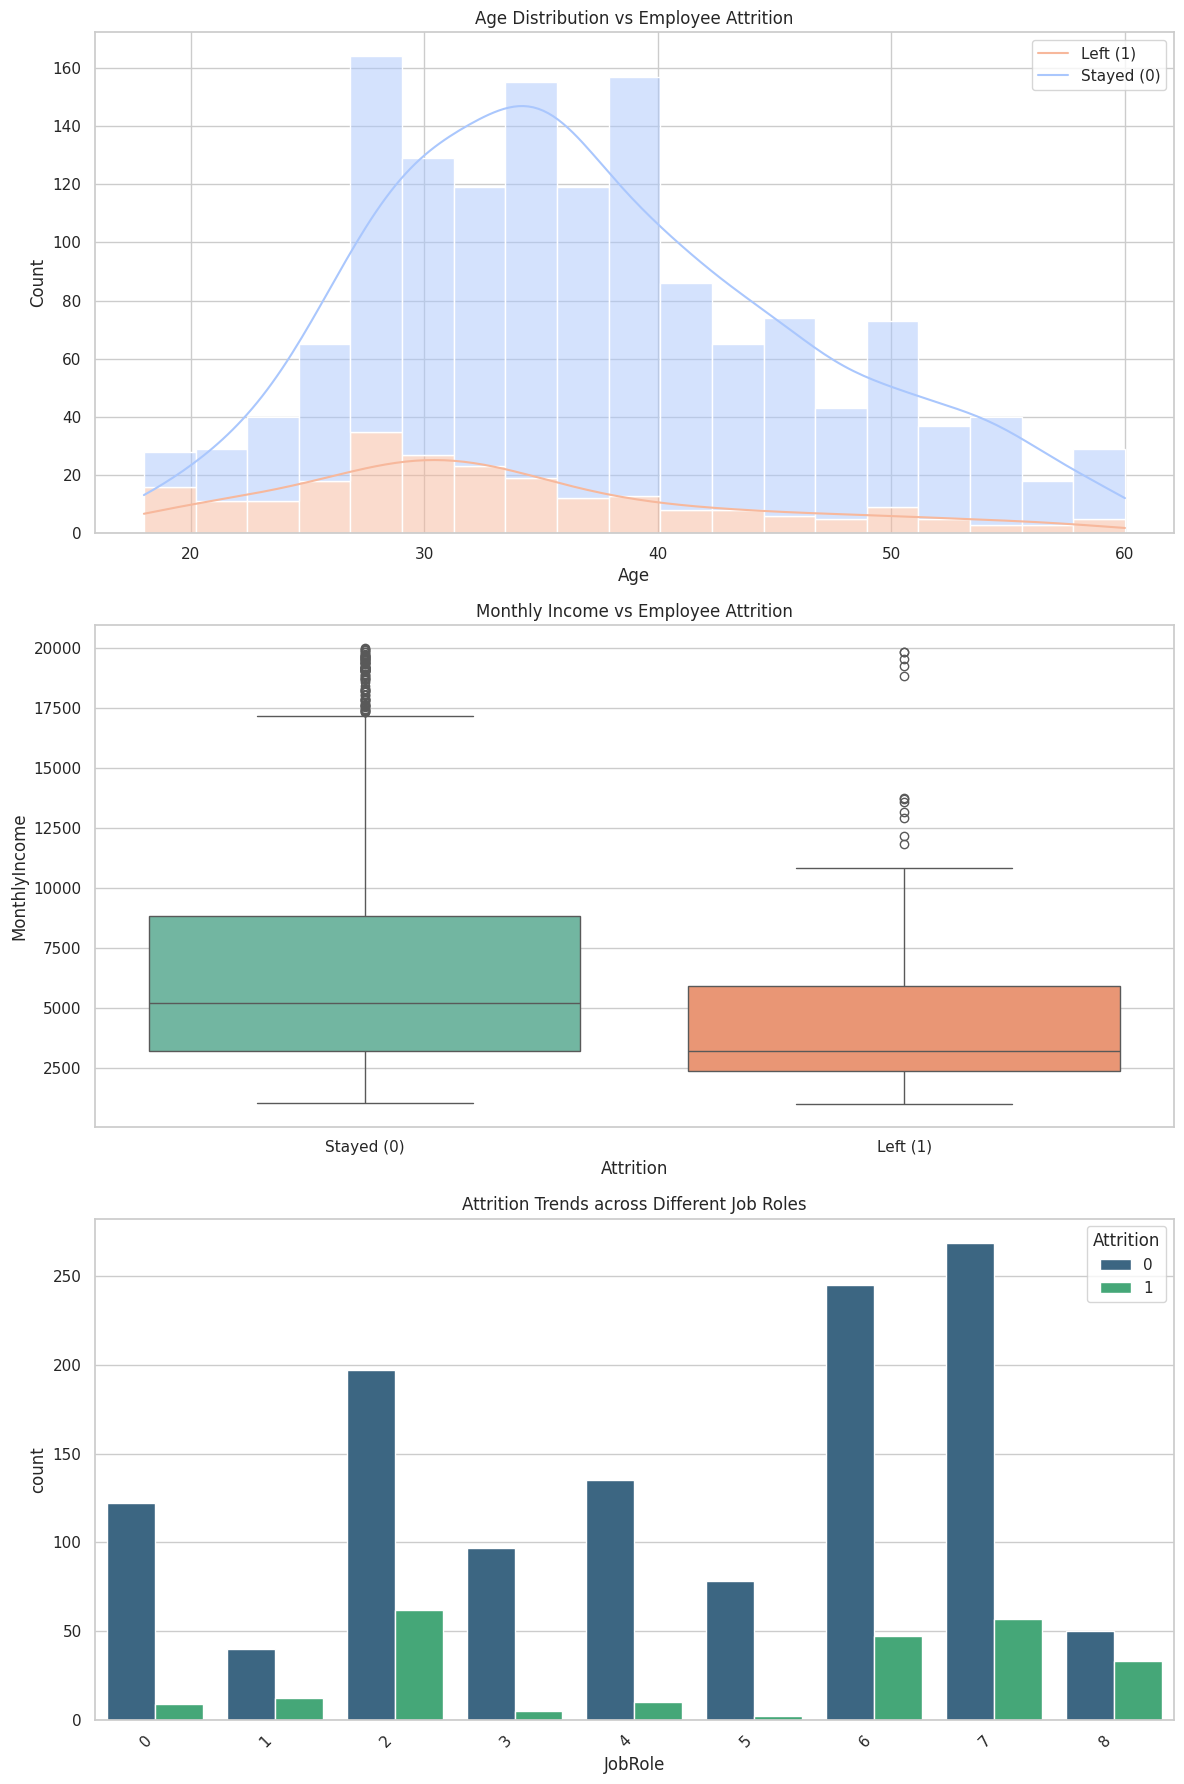

In [5]:
import warnings
warnings.filterwarnings('ignore')

# 1. Encode the remaining text columns to numbers
categorical_cols = df.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Set up the visualization style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Plot 1: Age Distribution by Attrition Status
sns.histplot(ax=axes[0], data=df, x='Age', hue='Attrition', kde=True, multiple='stack', palette='coolwarm')
axes[0].set_title('Age Distribution vs Employee Attrition')
axes[0].legend(['Left (1)', 'Stayed (0)'])

# Plot 2: Monthly Income Boxplot vs Attrition
sns.boxplot(ax=axes[1], data=df, x='Attrition', y='MonthlyIncome', palette='Set2')
axes[1].set_title('Monthly Income vs Employee Attrition')
axes[1].set_xticklabels(['Stayed (0)', 'Left (1)'])

# Plot 3: Attrition Count across Job Roles
sns.countplot(ax=axes[2], data=df, x='JobRole', hue='Attrition', palette='viridis')
axes[2].set_title('Attrition Trends across Different Job Roles')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [6]:
# 1. Split the data into features (X) and target variable (y)
# We drop 'Attrition' because it's what we want to predict, and 'EmployeeNumber' because it's just an ID
X = df.drop(['Attrition', 'EmployeeNumber'], axis=1)
y = df['Attrition']

# 2. Divide into Training set (80%) and Testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Train the Random Forest Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 4. Generate Predictions on the Test Set
y_pred = rf_model.predict(X_test)

# 5. Print out the Performance Evaluation Metrics
print(f"--- MODEL PERFORMANCE ACCURACY ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

--- MODEL PERFORMANCE ACCURACY ---
Accuracy Score: 83.67%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.45      0.11      0.17        47

    accuracy                           0.84       294
   macro avg       0.65      0.54      0.54       294
weighted avg       0.79      0.84      0.79       294



In [7]:
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE to balance the training data
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# 2. Retrain the Random Forest model on balanced data
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42)
rf_balanced.fit(X_train_balanced, y_train_balanced)

# 3. Generate new predictions
y_pred_balanced = rf_balanced.predict(X_test)

# 4. Evaluate the new balanced model
print(f"--- BALANCED MODEL PERFORMANCE ---")
print(f"New Accuracy Score: {accuracy_score(y_test, y_pred_balanced) * 100:.2f}%\n")
print("New Classification Report:")
print(classification_report(y_test, y_pred_balanced))

--- BALANCED MODEL PERFORMANCE ---
New Accuracy Score: 81.97%

New Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.92      0.90       247
           1       0.41      0.30      0.35        47

    accuracy                           0.82       294
   macro avg       0.64      0.61      0.62       294
weighted avg       0.80      0.82      0.81       294

